### Libraries

In [1]:
!pip install wget
import wget

In [2]:
from __future__ import print_function, division
import os
import torch
import numpy as np
import random

from torch.utils.data import DataLoader
from torch.utils.data.sampler import Sampler
from torchvision.datasets import VOCDetection

import tarfile

import skimage.io
import skimage.transform
import skimage.color
import skimage

from torchvision import transforms

from PIL import Image
import xml.etree.ElementTree as ET

import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from PIL import ImageDraw, ImageFont

import torch.nn as nn
import torch

import math
import torch.utils.model_zoo as model_zoo
from torchvision.ops import nms

## Load dataset: VOC2007
---
### Complete the following transformation modules
* Normalizer: Implement a Normalizer that normalizes an image using the RGB mean and standard deviation.
* Augmenter: Implement an Augmenter that horizontally flips an image with a 0.5 probability.

In [3]:
class Resizer(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample, min_side=608, max_side=1024):
        image, annots = sample['img'], sample['annot']

        rows, cols, cns = image.shape

        smallest_side = min(rows, cols)

        # rescale the image so the smallest side is min_side
        scale = min_side / smallest_side

        # check if the largest side is now greater than max_side, which can happen
        # when images have a large aspect ratio
        largest_side = max(rows, cols)

        if largest_side * scale > max_side:
            scale = max_side / largest_side

        # resize the image with the computed scale
        image = skimage.transform.resize(image, (int(round(rows*scale)), int(round((cols*scale)))))
        rows, cols, cns = image.shape

        pad_w = 32 - rows%32
        pad_h = 32 - cols%32

        new_image = np.zeros((rows + pad_w, cols + pad_h, cns)).astype(np.float32)
        new_image[:rows, :cols, :] = image.astype(np.float32)

        annots[:, :4] *= scale

        return {'img': torch.from_numpy(new_image), 'annot': torch.from_numpy(annots), 'scale': scale}


class Augmenter(object):
    def __call__(self, sample, flip_x=0.5):
        #################################
        # TODO: complete this module. #
        #################################
        # Augmenter is a module that augments the training set.
        # Implement and use an Augmentor that includes at least horizontal flipping with probability 0.5
        # as part of the augmentation process.

        # [START]
        if random.random() < flip_x:
            img = sample['img']
            sample['img'] = np.fliplr(img)
            annots = sample['annot']
            width = img.shape[1]
            x1 = annots[:, 0].copy()
            x2 = annots[:, 2].copy()
            annots[:, 0] = width - x2
            annots[:, 2] = width - x1
            sample['annot'] = annots
        return sample
        # [END]


class Normalizer(object):
    def __init__(self):
        self.mean = np.array([[[0.485, 0.456, 0.406]]])
        self.std = np.array([[[0.229, 0.224, 0.225]]])

    def __call__(self, sample):
        #################################
        # TODO: complete this module. #
        #################################
        # Implement a Normalizer that normalizes an image using the RGB mean and standard deviation.

        # [START]
        img = sample['img']
        img = (img - self.mean) / self.std
        sample['img'] = img
        return sample
        # [END]


class UnNormalizer(object):
    def __init__(self, mean=None, std=None):
        if mean == None:
            self.mean = [0.485, 0.456, 0.406]
        else:
            self.mean = mean
        if std == None:
            self.std = [0.229, 0.224, 0.225]
        else:
            self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

## VOC Dataset
---
Automatically download and use the VOC2007 dataset if it is not available.    
Complete the VOCDataset class.

In [4]:
def VOC_download(root_dir, year="2007"):
    if os.path.exists(os.path.join(root_dir, 'VOCdevkit')):
        print("VOC exists.")
        return

    urls = {
        "2007": {
            "trainval": "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar",
            "test": "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar"
        },
    }

    if year not in urls:
        raise ValueError("Only VOC 2007 and 2012 are supported")

    trainval_download_path = os.path.join(root_dir, f"VOC{year}.tar")

    print(f"Downloading VOC {year} train/val data...")
    wget.download(urls[year]["trainval"], trainval_download_path)

    with tarfile.open(trainval_download_path, "r") as tar:
        tar.extractall(root_dir)

    os.remove(trainval_download_path)

    if year == "2007":
        test_download_path = os.path.join(root_dir, f"VOC{year}_test.tar")
        print(f"\nDownloading VOC {year} test data...")
        wget.download(urls[year]["test"], test_download_path)

        with tarfile.open(test_download_path, "r") as tar:
            tar.extractall(root_dir)

        os.remove(test_download_path)


class VOCDataset(VOCDetection):
    def __init__(self, root_dir, year="2007", image_set="trainval", transform=False, download=True):
        self.root_dir = root_dir
        self.year = year
        self.image_set = image_set

        if download:
            VOC_download(root_dir=self.root_dir, year=self.year)

        if transform:
            if image_set == 'trainval':
                self.transform = transforms.Compose([Normalizer(), Augmenter(), Resizer()])
            elif image_set == 'test':
                self.transform = transforms.Compose([Normalizer(), Resizer()])

        imageset_file = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "ImageSets", "Main", image_set + ".txt")

        ############################################################################
        # TODO: assign appropriate values to 'self.image_ids' and 'self.classes'   #
        ############################################################################
        # self.image_ids: A list containing image names as elements.
        # self.classes: Class names defined in the order they exist in the VOC dataset.
        # [START]

        self.image_ids = [line.strip() for line in open(imageset_file, 'r').readlines()]
        self.classes = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

        self.class_to_ind = dict(zip(self.classes, range(len(self.classes))))
        # [END]


    def num_classes(self):
        return len(self.classes)


    def __len__(self):
        return len(self.image_ids)


    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        image_path = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "JPEGImages", image_id + ".jpg")
        img = Image.open(image_path).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0

        annotation_path = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "Annotations", image_id + ".xml")
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        annots = []
        #################################################
        # TODO: assign appropriate values to 'annots'   #
        #################################################
        # [START]
        for obj in root.findall('object'):
            boxes = obj.find('bndbox')
            x1 = float(boxes.find('xmin').text)
            y1 = float(boxes.find('ymin').text)
            x2 = float(boxes.find('xmax').text)
            y2 = float(boxes.find('ymax').text)
            class_name = obj.find('name').text
            class_id = self.class_to_ind[class_name]
            annots.append([x1, y1, x2, y2, class_id])

        if len(annots) == 0:
            annots = np.zeros((0, 5))
        else:
            annots = np.array(annots)
        # [END]

        sample = {'img': img, 'annot': annots}
        if self.transform:
            sample = self.transform(sample)
        return sample


    def image_aspect_ratio(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "JPEGImages", image_id + ".jpg")
        img = Image.open(image_path)
        return float(img.width) / float(img.height)


class AspectRatioBasedSampler(Sampler):
    def __init__(self, data_source, batch_size, drop_last):
        self.data_source = data_source
        self.batch_size = batch_size
        self.drop_last = drop_last
        self.groups = self.group_images()

    def __iter__(self):
        random.shuffle(self.groups)
        for group in self.groups:
            yield group

    def __len__(self):
        if self.drop_last:
            return len(self.data_source) // self.batch_size
        else:
            return (len(self.data_source) + self.batch_size - 1) // self.batch_size

    def group_images(self):
        # determine the order of the images
        order = list(range(len(self.data_source)))
        order.sort(key=lambda x: self.data_source.image_aspect_ratio(x))

        # divide into groups, one group = one batch
        return [[order[x % len(order)] for x in range(i, i + self.batch_size)] for i in range(0, len(order), self.batch_size)]

In [5]:
path2data = './VOC'
if not os.path.exists(path2data):
    os.mkdir(path2data)

In [6]:
dataset_train = VOCDataset(root_dir=path2data, year="2007", image_set="trainval", transform=True)
dataset_val = VOCDataset(root_dir=path2data, year="2007", image_set="test", transform=True)

VOC exists.
VOC exists.


## Visualization
---
Let's examine how the ground truth data is structured.

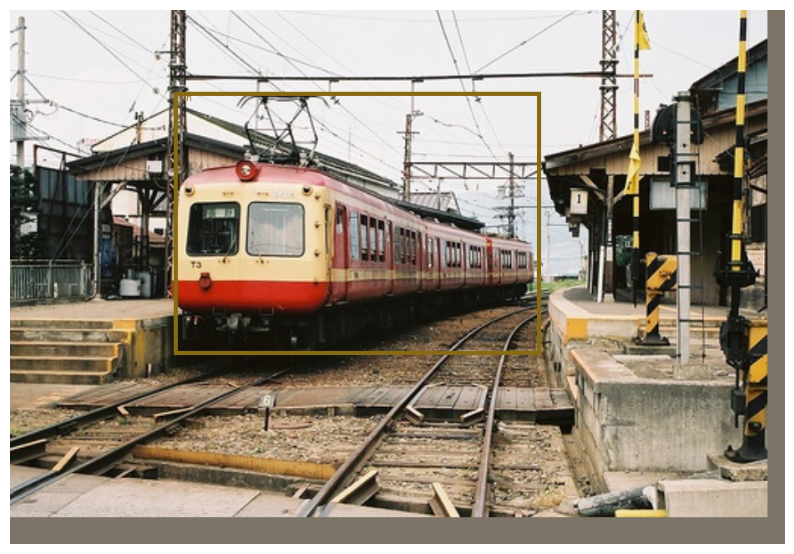

In [7]:
##########################
# TODO: get 'classes'    #
##########################
# [START]

classes = dataset_val.classes

# [END]

colors = np.random.randint(0, 255, size=(len(classes), 3), dtype='uint8')

def show_sample(sample, classes=classes, colors=colors, GT=True, model=None):
    # permute (H, W, C) => (C, H, W)
    img = sample['img']
    img = img.permute(2, 0, 1) # (C, H, W)

    unorm = UnNormalizer()
    img = unorm(img.clone())
    img = torch.clamp(img, 0, 1)

    pil_img = to_pil_image(img)
    draw = ImageDraw.Draw(pil_img)

    if GT:
        annot = sample['annot']
        if torch.is_tensor(annot):
            annot = annot.cpu().numpy()

        for box in annot:
            if box[0] < 0:
                continue
            x1, y1, x2, y2, cls_idx = box
            cls_idx = int(cls_idx)
            color = tuple(int(c) for c in colors[cls_idx])
            label = classes[cls_idx]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=5)
            draw.text((x1, y1), label, fill=color)
            # font = ImageFont.truetype("arial.ttf", 20)
            # draw.text((x1, y1), label, fill=color, font=font)
    else:
        with torch.no_grad():
            model.eval()
            finalScores, finalAnchorBoxesIndexes, finalAnchorBoxesCoordinates = model(img.unsqueeze(0).cuda().float())
            finalScores = finalScores.cpu()
            finalAnchorBoxesIndexes = finalAnchorBoxesIndexes.cpu()
            finalAnchorBoxesCoordinates = finalAnchorBoxesCoordinates.cpu()

            for score, cls_idx, box in zip(finalScores, finalAnchorBoxesIndexes, finalAnchorBoxesCoordinates):
                x1, y1, x2, y2 = box.int().tolist()
                cls_idx = int(cls_idx)
                color = tuple(int(c) for c in colors[cls_idx])
                label = classes[cls_idx]
                draw.rectangle([x1, y1, x2, y2], outline=color, width=5)
                draw.text((x1, y1), f'{label}-{score}', fill=color)

    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(pil_img))
    plt.axis('off')
    plt.show()

sample = dataset_val[123]
show_sample(sample)

### Dataloaders & collater function
---
The VOC dataset comprises samples containing images of various sizes and a variable number of bounding boxes. We process this dataset in batches, and to handle samples with different formats, we implement and utilize a collater function. For more details, refer to the [official PyTorch documentation](https://pytorch.org/docs/stable/data.html#loading-batched-and-non-batched-data).

In [8]:
def collater(data):
    imgs = [s['img'] for s in data]
    annots = [s['annot'] for s in data]
    scales = [s['scale'] for s in data]

    widths = [int(s.shape[0]) for s in imgs]
    heights = [int(s.shape[1]) for s in imgs]
    batch_size = len(imgs)

    max_width = np.array(widths).max()
    max_height = np.array(heights).max()

    padded_imgs = torch.zeros(batch_size, max_width, max_height, 3)

    for i in range(batch_size):
        img = imgs[i]
        padded_imgs[i, :int(img.shape[0]), :int(img.shape[1]), :] = img

    max_num_annots = max(annot.shape[0] for annot in annots)

    if max_num_annots > 0:

        annot_padded = torch.ones((len(annots), max_num_annots, 5)) * -1

        if max_num_annots > 0:
            for idx, annot in enumerate(annots):
                if annot.shape[0] > 0:
                    annot_padded[idx, :annot.shape[0], :] = annot
    else:
        annot_padded = torch.ones((len(annots), 1, 5)) * -1


    padded_imgs = padded_imgs.permute(0, 3, 1, 2)

    #################################################
    # TODO: complete return                         #
    #################################################
    # [START]

    return {'img': padded_imgs, 'annot': annot_padded, 'scale': torch.tensor(scales)}

    # [END]

In [9]:
# Adjust the batch size to suit your GPU environment.
# Select the largest possible batch size that your GPU memory allows. The choice is yours.
#BATCH size 조절 파라미터
BATCH_SIZE = 24

#########################################################################
# TODO: Initialize dataloader_train and dataloader_val with collater()  #
#########################################################################
# [START]

sampler = AspectRatioBasedSampler(dataset_train, batch_size=BATCH_SIZE, drop_last=False)
dataloader_train = DataLoader(dataset_train, batch_sampler=sampler, collate_fn=collater)

sampler_val = AspectRatioBasedSampler(dataset_val, batch_size=1, drop_last=False)
dataloader_val = DataLoader(dataset_val, batch_sampler=sampler_val, collate_fn=collater)

# [END]

## Implementation of RetinaNet
---
[Paper: Focal Loss for Dense Object Detection](https://arxiv.org/pdf/1708.02002)    
[Paper: Feature Pyramid Networks for Object Detection](https://arxiv.org/pdf/1612.03144)    
The RetinaNet model is a one-stage object detection model incorporating features such as Focal Loss, a Feature Pyramid Network (FPN), and various architectural improvements. These enhancements provide a unique balance between speed and accuracy, making RetinaNet a unique model.

Object detection, a core task in computer vision, involves finding and classifying objects within images or videos. This underpins applications like self-driving cars, security surveillance, and augmented reality.

Our goal is to implement RetinaNet, train it on the VOC dataset, and perform object detection on the test set using our model. RetinaNet consists of a pretrained backbone (ResNet101 is used in this assignment), a Feature Pyramid Network, a classification subnetwork, and a regression subnetwork. The classification model classifies which class an object belongs to, while the regression model performs bounding-box regression. RetinaNet utilizes an FPN to generate feature maps of different resolutions, enabling effective detection of objects ranging from small to large. FPN takes as input the feature maps extracted from the last three stages (C3, C4, and C5) of ResNet, and based on these, it constructs a five-level multi-scale feature pyramid (P3–P7), which are then passed to the classification and regression models. The classification model predicts the class of each anchor, while the regression model predicts the offset for each anchor.

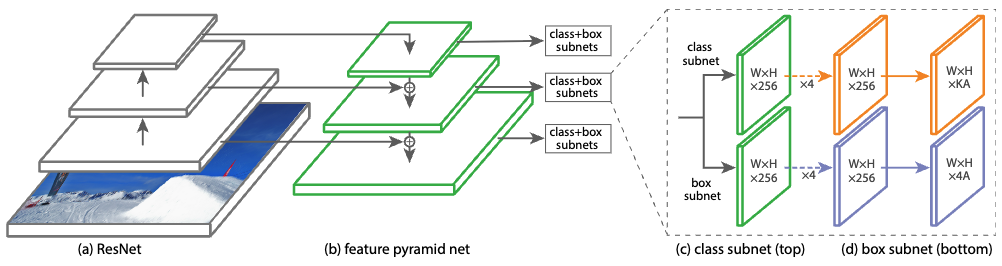

In [10]:
#########################################
# TODO: complete this PyramidFeatures   #
# upsample mode: nearest                #
#########################################
# [START]
class PyramidFeatures(nn.Module):
    def __init__(self):
        super(PyramidFeatures, self).__init__()
        self.c3 = nn.Conv2d(512, 256, 1)
        self.c4 = nn.Conv2d(1024, 256, 1)
        self.c5 = nn.Conv2d(2048, 256, 1)
        self.p3 = nn.Conv2d(256, 256, 3, padding=1)
        self.p4 = nn.Conv2d(256, 256, 3, padding=1)
        self.p5 = nn.Conv2d(256, 256, 3, padding=1)
        self.p6_conv = nn.Conv2d(256, 256, 3, stride=2, padding=1)
        self.p7_conv = nn.Conv2d(256, 256, 3, stride=2, padding=1)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, inputs):
        c3, c4, c5 = inputs
        m3 = self.c3(c3)
        m4 = self.c4(c4)
        m5 = self.c5(c5)
        p5 = self.p5(m5)
        p4 = self.p4(m4 + self.upsample(p5))
        p3 = self.p3(m3 + self.upsample(p4))
        p6 = self.p6_conv(p5)
        p7 = self.p7_conv(p6)
        return p3, p4, p5, p6, p7
# [END]
#########################################
# TODO: complete this RegressionModel   #
#########################################
# [START]
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.conv1 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv2 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 256, 3, padding=1)
        self.output = nn.Conv2d(256, 36, 3, padding=1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.output(x)
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(x.shape[0], x.shape[1], x.shape[2], 9, 4)
        return x.view(x.shape[0], -1, 4)
# [END]
#############################################
# TODO: complete this ClassificationModel   #
#############################################
# [START]
class ClassificationModel(nn.Module):
    def __init__(self, num_classes=20, num_anchors=9):
        super(ClassificationModel, self).__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.conv1 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv2 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 256, 3, padding=1)
        self.output = nn.Conv2d(256, num_anchors * num_classes, 3, padding=1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.output(x)
        x = torch.sigmoid(x)
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(x.shape[0], x.shape[1], x.shape[2], self.num_anchors, self.num_classes)
        return x.view(x.shape[0], -1, self.num_classes)

In [11]:
model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

#############################################
# TODO: complete BBoxTransform module       #
#############################################
# [START]
class BBoxTransform(nn.Module):
    def __init__(self, mean=None, std=None):
        super(BBoxTransform, self).__init__()
        if mean is None:
            self.mean = torch.from_numpy(np.array([0, 0, 0, 0]).astype(np.float32)).cuda()
        else:
            self.mean = mean
        if std is None:
            self.std = torch.from_numpy(np.array([0.1, 0.1, 0.2, 0.2]).astype(np.float32)).cuda()
        else:
            self.std = std

    def forward(self, boxes, deltas):
        w = boxes[:, :, 2] - boxes[:, :, 0]  # x2 - x1
        h = boxes[:, :, 3] - boxes[:, :, 1]  # y2 - y1
        ctr_x = boxes[:, :, 0] + 0.5 * w
        ctr_y = boxes[:, :, 1] + 0.5 * h
        
        dx = deltas[:, :, 0]
        dy = deltas[:, :, 1]
        dw = deltas[:, :, 2]
        dh = deltas[:, :, 3]
        dx = dx * self.std[0] + self.mean[0]
        dy = dy * self.std[1] + self.mean[1]
        dw = dw * self.std[2] + self.mean[2]
        dh = dh * self.std[3] + self.mean[3]
        
        pred_ctr_x = dx * w + ctr_x
        pred_ctr_y = dy * h + ctr_y
        pred_w = torch.exp(dw) * w
        pred_h = torch.exp(dh) * h
        
        boxes[:, :, 0] = pred_ctr_x - 0.5 * pred_w
        boxes[:, :, 1] = pred_ctr_y - 0.5 * pred_h
        boxes[:, :, 2] = pred_ctr_x + 0.5 * pred_w
        boxes[:, :, 3] = pred_ctr_y + 0.5 * pred_h
        
        return boxes
# [END]

class ClipBoxes(nn.Module):
    def __init__(self, width=None, height=None):
        super(ClipBoxes, self).__init__()

    def forward(self, boxes, img):
        batch_size, num_channels, height, width = img.shape

        boxes[:, :, 0] = torch.clamp(boxes[:, :, 0], min=0)
        boxes[:, :, 1] = torch.clamp(boxes[:, :, 1], min=0)

        boxes[:, :, 2] = torch.clamp(boxes[:, :, 2], max=width)
        boxes[:, :, 3] = torch.clamp(boxes[:, :, 3], max=height)

        return boxes


####################################################################################
# TODO: complete Anchor class, generate_anchors functions and shift function       #
####################################################################################
# generate_anchors():
#   base anchor boxes are generated using the given base size (e.g., 32, 64, …),
#   along with the specified ratios and scales.
# shift():
#   the generated base anchors are then shifted to align with
#   the center of each cell of the feature map.

# [START]
class Anchors(nn.Module):
    def __init__(self, pyramid_levels=None, strides=None, sizes=None, ratios=None, scales=None):
        super(Anchors, self).__init__()
        if pyramid_levels is None:
            self.pyramid_levels = [3, 4, 5, 6, 7]
        else:
            self.pyramid_levels = pyramid_levels
        if strides is None:
            self.strides = [2 ** x for x in self.pyramid_levels]
        else:
            self.strides = strides
        if sizes is None:
            self.sizes = [2 ** (x + 2) for x in self.pyramid_levels]
        else:
            self.sizes = sizes
        if ratios is None:
            self.ratios = np.array([0.5, 1, 2])
        else:
            self.ratios = ratios
        if scales is None:
            self.scales = np.array([2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])
        else:
            self.scales = scales

    def forward(self, image):
        image_shape = image.shape[2:]
        image_shape = np.array(image_shape)
        image_shapes = [(image_shape + 2 ** x - 1) // (2 ** x) for x in self.pyramid_levels]
        all_anchors = np.empty((0, 4))

        for idx, p in enumerate(self.pyramid_levels):
            anchors         = generate_anchors(self.sizes[idx], self.ratios, self.scales)
            shifted_anchors = shift(image_shapes[idx], self.strides[idx], anchors)
            all_anchors     = np.append(all_anchors, shifted_anchors, axis=0)

        all_anchors = np.expand_dims(all_anchors, axis=0)
        return torch.from_numpy(all_anchors.astype(np.float32)).cuda()


def generate_anchors(base_size, ratios, scales):
    """Generate base anchor boxes with different ratios and scales."""
    num_anchors = len(ratios) * len(scales)
    anchors = np.zeros((num_anchors, 4))
    idx = 0
    for i in range(len(ratios)):
        for j in range(len(scales)):
            ratio = ratios[i]
            scale = scales[j]
            
            w = base_size * np.sqrt(1.0 / ratio) * scale
            h = base_size * np.sqrt(ratio) * scale
            
            anchors[idx, 0] = -w / 2
            anchors[idx, 1] = -h / 2
            anchors[idx, 2] = w / 2
            anchors[idx, 3] = h / 2
            
            idx += 1
    
    return anchors

def shift(shape, stride, anchors):
    """Shift base anchors to align with feature map grid."""
    shift_x = (np.arange(0, shape[1]) + 0.5) * stride
    shift_y = (np.arange(0, shape[0]) + 0.5) * stride
    
    shift_x, shift_y = np.meshgrid(shift_x, shift_y)
    
    shifts = np.vstack((shift_x.ravel(), shift_y.ravel(),
                        shift_x.ravel(), shift_y.ravel())).transpose()
    
    all_anchors = anchors[np.newaxis, :, :] + shifts[:, np.newaxis, :]
    all_anchors = all_anchors.reshape((-1, 4))
    
    return all_anchors


class ResNet(nn.Module):
    def __init__(self, num_classes, block, layers):
        self.inplanes = 64
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        if block == BasicBlock:
            fpn_sizes = [self.layer2[layers[1] - 1].conv2.out_channels, self.layer3[layers[2] - 1].conv2.out_channels,
                         self.layer4[layers[3] - 1].conv2.out_channels]
        elif block == Bottleneck:
            fpn_sizes = [self.layer2[layers[1] - 1].conv3.out_channels, self.layer3[layers[2] - 1].conv3.out_channels,
                         self.layer4[layers[3] - 1].conv3.out_channels]
        else:
            raise ValueError(f"Block type {block} not understood")

        ####################################################################################
        # TODO: fill the components.                                                       #
        ####################################################################################
        # [START]
        self.fpn = PyramidFeatures()
        self.regressionModel = RegressionModel()
        self.classificationModel = ClassificationModel(num_classes=num_classes)
        self.anchors = Anchors()
        self.regressBoxes = BBoxTransform()
        # [END]

        self.clipBoxes = ClipBoxes()

        self.lossModule = None

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

        prior = 0.01

        self.classificationModel.output.weight.data.fill_(0)
        self.classificationModel.output.bias.data.fill_(-math.log((1.0 - prior) / prior))

        self.regressionModel.output.weight.data.fill_(0)
        self.regressionModel.output.bias.data.fill_(0)

        self.freeze_bn()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def freeze_bn(self):
        '''Freeze BatchNorm layers.'''
        for layer in self.modules():
            if isinstance(layer, nn.BatchNorm2d):
                layer.eval()

    def forward(self, inputs):
        if self.training:
            img_batch, annotations = inputs
        else:
            img_batch = inputs

        x = self.conv1(img_batch)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        features = self.fpn([x2, x3, x4])

        regression = torch.cat([self.regressionModel(feature) for feature in features], dim=1)

        classification = torch.cat([self.classificationModel(feature) for feature in features], dim=1)

        anchors = self.anchors(img_batch)

        if self.training:
            return self.lossModule(classification, regression, anchors, annotations)
        else:
            transformed_anchors = self.regressBoxes(anchors, regression)
            transformed_anchors = self.clipBoxes(transformed_anchors, img_batch)

            finalResult = [[], [], []]

            finalScores = torch.Tensor([])
            finalAnchorBoxesIndexes = torch.Tensor([]).long()
            finalAnchorBoxesCoordinates = torch.Tensor([])

            finalScores = finalScores.cuda()
            finalAnchorBoxesIndexes = finalAnchorBoxesIndexes.cuda()
            finalAnchorBoxesCoordinates = finalAnchorBoxesCoordinates.cuda()

            for i in range(classification.shape[2]):
                scores = torch.squeeze(classification[:, :, i])
                scores_over_thresh = (scores > 0.05)
                if scores_over_thresh.sum() == 0:
                    # no boxes to NMS, just continue
                    continue

                scores = scores[scores_over_thresh]
                anchorBoxes = torch.squeeze(transformed_anchors)
                anchorBoxes = anchorBoxes[scores_over_thresh]
                anchors_nms_idx = nms(anchorBoxes, scores, 0.5)

                finalResult[0].extend(scores[anchors_nms_idx])
                finalResult[1].extend(torch.tensor([i] * anchors_nms_idx.shape[0]))
                finalResult[2].extend(anchorBoxes[anchors_nms_idx])

                finalScores = torch.cat((finalScores, scores[anchors_nms_idx]))
                finalAnchorBoxesIndexesValue = torch.tensor([i] * anchors_nms_idx.shape[0])
                finalAnchorBoxesIndexesValue = finalAnchorBoxesIndexesValue.cuda()

                finalAnchorBoxesIndexes = torch.cat((finalAnchorBoxesIndexes, finalAnchorBoxesIndexesValue))
                finalAnchorBoxesCoordinates = torch.cat((finalAnchorBoxesCoordinates, anchorBoxes[anchors_nms_idx]))

            return [finalScores, finalAnchorBoxesIndexes, finalAnchorBoxesCoordinates]


def resnet101(num_classes, pretrained=False, **kwargs):
    """Constructs a ResNet-101 model.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(num_classes, Bottleneck, [3, 4, 23, 3], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url(model_urls['resnet101'], model_dir='.'), strict=False)
    return model

In [12]:
retinanet = resnet101(num_classes=dataset_train.num_classes(), pretrained=True)
retinanet = retinanet.cuda()

In [13]:
optimizer = optim.Adam(retinanet.parameters(), lr=1e-5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

## Train: BCE Loss
---
Implement the training step


In [14]:
def calc_iou(a, b):
    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])

    iw = torch.min(torch.unsqueeze(a[:, 2], dim=1), b[:, 2]) - torch.max(torch.unsqueeze(a[:, 0], 1), b[:, 0])
    ih = torch.min(torch.unsqueeze(a[:, 3], dim=1), b[:, 3]) - torch.max(torch.unsqueeze(a[:, 1], 1), b[:, 1])

    iw = torch.clamp(iw, min=0)
    ih = torch.clamp(ih, min=0)

    ua = torch.unsqueeze((a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]), dim=1) + area - iw * ih

    ua = torch.clamp(ua, min=1e-8)

    intersection = iw * ih

    IoU = intersection / ua

    return IoU

class BinaryCrossEntropyLoss(nn.Module):
    def forward(self, classifications, regressions, anchors, annotations):
        batch_size = classifications.shape[0]
        classification_losses = []
        regression_losses = []

        anchor = anchors[0, :, :]

        anchor_widths  = anchor[:, 2] - anchor[:, 0]
        anchor_heights = anchor[:, 3] - anchor[:, 1]
        anchor_ctr_x   = anchor[:, 0] + 0.5 * anchor_widths
        anchor_ctr_y   = anchor[:, 1] + 0.5 * anchor_heights

        for j in range(batch_size):

            classification = classifications[j, :, :]
            regression = regressions[j, :, :]

            bbox_annotation = annotations[j, :, :]
            bbox_annotation = bbox_annotation[bbox_annotation[:, 4] != -1]

            classification = torch.clamp(classification, 1e-4, 1.0 - 1e-4)

            if bbox_annotation.shape[0] == 0:
                bce = -(torch.log(1.0 - classification))
                cls_loss = bce
                classification_losses.append(cls_loss.sum())
                regression_losses.append(torch.tensor(0).float().cuda())
                continue

            IoU = calc_iou(anchors[0, :, :], bbox_annotation[:, :4]) # num_anchors x num_annotations

            IoU_max, IoU_argmax = torch.max(IoU, dim=1) # num_anchors x 1

            # compute the loss for classification
            targets = torch.ones(classification.shape) * -1
            targets = targets.cuda()

            targets[torch.lt(IoU_max, 0.4), :] = 0

            positive_indices = torch.ge(IoU_max, 0.5)
            num_positive_anchors = positive_indices.sum()

            assigned_annotations = bbox_annotation[IoU_argmax, :]

            targets[positive_indices, :] = 0
            targets[positive_indices, assigned_annotations[positive_indices, 4].long()] = 1

            bce = -(targets * torch.log(classification) + (1.0 - targets) * torch.log(1.0 - classification))

            cls_loss = bce
            cls_loss = torch.where(torch.ne(targets, -1.0), cls_loss, torch.zeros(cls_loss.shape).cuda())
            classification_losses.append(cls_loss.sum()/torch.clamp(num_positive_anchors.float(), min=1.0))

            # compute the loss for regression
            if positive_indices.sum() > 0:
                assigned_annotations = assigned_annotations[positive_indices, :]

                anchor_widths_pi = anchor_widths[positive_indices]
                anchor_heights_pi = anchor_heights[positive_indices]
                anchor_ctr_x_pi = anchor_ctr_x[positive_indices]
                anchor_ctr_y_pi = anchor_ctr_y[positive_indices]

                gt_widths  = assigned_annotations[:, 2] - assigned_annotations[:, 0]
                gt_heights = assigned_annotations[:, 3] - assigned_annotations[:, 1]
                gt_ctr_x   = assigned_annotations[:, 0] + 0.5 * gt_widths
                gt_ctr_y   = assigned_annotations[:, 1] + 0.5 * gt_heights

                # clip widths to 1
                gt_widths  = torch.clamp(gt_widths, min=1)
                gt_heights = torch.clamp(gt_heights, min=1)

                targets_dx = (gt_ctr_x - anchor_ctr_x_pi) / anchor_widths_pi
                targets_dy = (gt_ctr_y - anchor_ctr_y_pi) / anchor_heights_pi
                targets_dw = torch.log(gt_widths / anchor_widths_pi)
                targets_dh = torch.log(gt_heights / anchor_heights_pi)

                targets = torch.stack((targets_dx, targets_dy, targets_dw, targets_dh))
                targets = targets.t()

                targets = targets/torch.Tensor([[0.1, 0.1, 0.2, 0.2]]).cuda()

                regression_diff = torch.abs(targets - regression[positive_indices, :])

                regression_loss = torch.where(
                    torch.le(regression_diff, 1.0 / 9.0),
                    0.5 * 9.0 * torch.pow(regression_diff, 2),
                    regression_diff - 0.5 / 9.0
                )
                regression_losses.append(regression_loss.mean())
            else:
                regression_losses.append(torch.tensor(0).float().cuda())

        return torch.stack(classification_losses).mean(dim=0, keepdim=True), torch.stack(regression_losses).mean(dim=0, keepdim=True)

In [15]:
retinanet.lossModule = BinaryCrossEntropyLoss()
retinanet.train()
retinanet.freeze_bn()

print('Num training images: {}'.format(len(dataset_train)))

#epoch 숫자 조절 파라미터
for epoch_num in range(20):
    retinanet.train()
    retinanet.freeze_bn()
    epoch_loss = []

    for iter_num, data in enumerate(dataloader_train):
        #############################################
        # TODO: complete following training steps   #
        #############################################
        # [START]
        optimizer.zero_grad()
        classification_loss, regression_loss = retinanet([data['img'].cuda().float(), data['annot'].cuda()])
        classification_loss = classification_loss.mean()
        regression_loss = regression_loss.mean()
        loss = classification_loss + regression_loss

        if loss == 0:
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(retinanet.parameters(), 0.1)
        optimizer.step()

        epoch_loss.append(float(loss))

        print('Epoch: {} | Iteration: {} | Classification loss: {:1.5f} | Regression loss: {:1.5f}'.format(epoch_num, iter_num, float(classification_loss), float(regression_loss)))

        del classification_loss
        del regression_loss
        # [END]

    scheduler.step(np.mean(epoch_loss))

retinanet.eval()
torch.save(retinanet, 'model_final_BCE.pt')

Num training images: 5011


/tmp/ipykernel_90219/2044081826.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  epoch_loss.append(float(loss))


Epoch: 0 | Iteration: 0 | Classification loss: 366.38434 | Regression loss: 1.06577
Epoch: 0 | Iteration: 1 | Classification loss: 501.09311 | Regression loss: 1.03082
Epoch: 0 | Iteration: 2 | Classification loss: 1175.45557 | Regression loss: 1.00169
Epoch: 0 | Iteration: 3 | Classification loss: 289.14789 | Regression loss: 1.05639
Epoch: 0 | Iteration: 4 | Classification loss: 330.07651 | Regression loss: 1.05883
Epoch: 0 | Iteration: 5 | Classification loss: 160.87476 | Regression loss: 1.03695
Epoch: 0 | Iteration: 6 | Classification loss: 117.80047 | Regression loss: 1.03927
Epoch: 0 | Iteration: 7 | Classification loss: 71.05829 | Regression loss: 1.01685
Epoch: 0 | Iteration: 8 | Classification loss: 61.34620 | Regression loss: 1.04027
Epoch: 0 | Iteration: 9 | Classification loss: 33.87711 | Regression loss: 1.06915
Epoch: 0 | Iteration: 10 | Classification loss: 23.81169 | Regression loss: 1.02501
Epoch: 0 | Iteration: 11 | Classification loss: 45.23188 | Regression loss: 0.

## Load trained RetinaNet and perform inference
---
Let's compare the ground truth and the model's predictions.

In [16]:
retinanet = torch.load('model_final_BCE.pt', weights_only=False, map_location='cpu')
retinanet = retinanet.cuda()
retinanet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

##### Ground truth

<class 'torch.Tensor'>


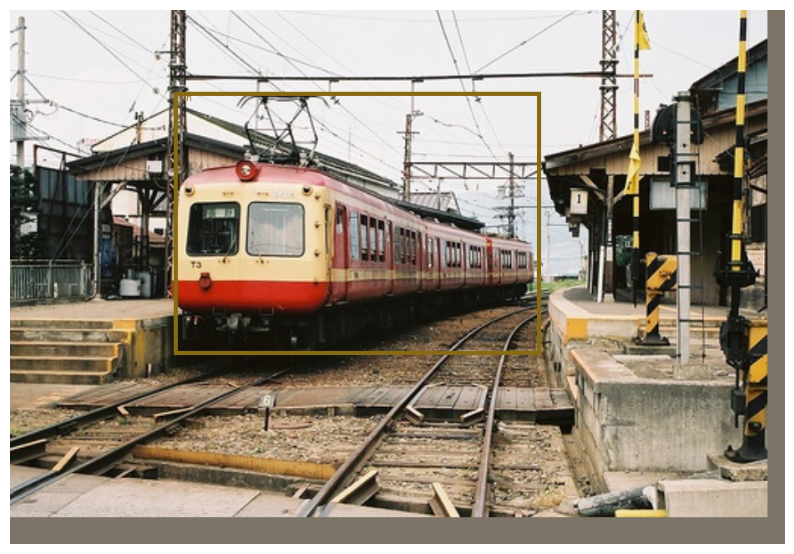

In [17]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=True)

##### Prediction

<class 'torch.Tensor'>


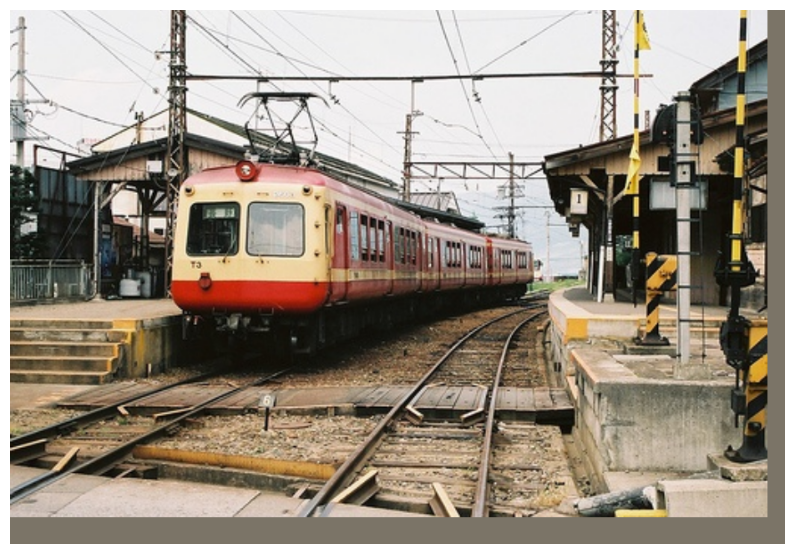

In [18]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=False, model=retinanet)

## Focal loss
---
Let's use Focal Loss instead of BCE Loss.    

In object detection, the background is much more prevalent than the objects, which makes the background an easier target to predict. [Focal loss](https://arxiv.org/pdf/1708.02002) was proposed to address this issue by, compared to BCE loss, assigning a smaller loss to well-classified targets (background) and a larger loss to hard-to-classify samples (objects), thereby mitigating the imbalance problem.

In [19]:
class FocalLoss(nn.Module):
    def forward(self, classifications, regressions, anchors, annotations):
        alpha = 0.25
        gamma = 2.0
        batch_size = classifications.shape[0]
        classification_losses = []
        regression_losses = []

        anchor = anchors[0, :, :]

        anchor_widths  = anchor[:, 2] - anchor[:, 0]
        anchor_heights = anchor[:, 3] - anchor[:, 1]
        anchor_ctr_x   = anchor[:, 0] + 0.5 * anchor_widths
        anchor_ctr_y   = anchor[:, 1] + 0.5 * anchor_heights

        for j in range(batch_size):

            classification = classifications[j, :, :]
            regression = regressions[j, :, :]

            bbox_annotation = annotations[j, :, :]
            bbox_annotation = bbox_annotation[bbox_annotation[:, 4] != -1]

            classification = torch.clamp(classification, 1e-4, 1.0 - 1e-4)

            if bbox_annotation.shape[0] == 0:
                alpha_factor = torch.ones(classification.shape).cuda() * alpha

                alpha_factor = 1. - alpha_factor
                focal_weight = classification
                focal_weight = alpha_factor * torch.pow(focal_weight, gamma)

                bce = -(torch.log(1.0 - classification))

                cls_loss = focal_weight * bce
                classification_losses.append(cls_loss.sum())
                regression_losses.append(torch.tensor(0).float().cuda())
                continue

            IoU = calc_iou(anchors[0, :, :], bbox_annotation[:, :4]) # num_anchors x num_annotations

            IoU_max, IoU_argmax = torch.max(IoU, dim=1) # num_anchors x 1

            # compute the loss for classification
            targets = torch.ones(classification.shape) * -1
            targets = targets.cuda()

            targets[torch.lt(IoU_max, 0.4), :] = 0

            positive_indices = torch.ge(IoU_max, 0.5)
            num_positive_anchors = positive_indices.sum()

            assigned_annotations = bbox_annotation[IoU_argmax, :]

            targets[positive_indices, :] = 0
            targets[positive_indices, assigned_annotations[positive_indices, 4].long()] = 1

            alpha_factor = torch.ones(targets.shape).cuda() * alpha
            alpha_factor = torch.where(torch.eq(targets, 1.), alpha_factor, 1. - alpha_factor)

            focal_weight = torch.where(torch.eq(targets, 1.), 1. - classification, classification)
            focal_weight = alpha_factor * torch.pow(focal_weight, gamma)

            bce = -(targets * torch.log(classification) + (1.0 - targets) * torch.log(1.0 - classification))

            cls_loss = focal_weight * bce
            cls_loss = torch.where(torch.ne(targets, -1.0), cls_loss, torch.zeros(cls_loss.shape).cuda())
            classification_losses.append(cls_loss.sum()/torch.clamp(num_positive_anchors.float(), min=1.0))

            # compute the loss for regression
            if positive_indices.sum() > 0:
                assigned_annotations = assigned_annotations[positive_indices, :]

                anchor_widths_pi = anchor_widths[positive_indices]
                anchor_heights_pi = anchor_heights[positive_indices]
                anchor_ctr_x_pi = anchor_ctr_x[positive_indices]
                anchor_ctr_y_pi = anchor_ctr_y[positive_indices]

                gt_widths  = assigned_annotations[:, 2] - assigned_annotations[:, 0]
                gt_heights = assigned_annotations[:, 3] - assigned_annotations[:, 1]
                gt_ctr_x   = assigned_annotations[:, 0] + 0.5 * gt_widths
                gt_ctr_y   = assigned_annotations[:, 1] + 0.5 * gt_heights

                # clip widths to 1
                gt_widths  = torch.clamp(gt_widths, min=1)
                gt_heights = torch.clamp(gt_heights, min=1)

                targets_dx = (gt_ctr_x - anchor_ctr_x_pi) / anchor_widths_pi
                targets_dy = (gt_ctr_y - anchor_ctr_y_pi) / anchor_heights_pi
                targets_dw = torch.log(gt_widths / anchor_widths_pi)
                targets_dh = torch.log(gt_heights / anchor_heights_pi)

                targets = torch.stack((targets_dx, targets_dy, targets_dw, targets_dh))
                targets = targets.t()

                targets = targets/torch.Tensor([[0.1, 0.1, 0.2, 0.2]]).cuda()

                regression_diff = torch.abs(targets - regression[positive_indices, :])

                regression_loss = torch.where(
                    torch.le(regression_diff, 1.0 / 9.0),
                    0.5 * 9.0 * torch.pow(regression_diff, 2),
                    regression_diff - 0.5 / 9.0
                )
                regression_losses.append(regression_loss.mean())
            else:
                regression_losses.append(torch.tensor(0).float().cuda())

        return torch.stack(classification_losses).mean(dim=0, keepdim=True), torch.stack(regression_losses).mean(dim=0, keepdim=True)

In [20]:
try:
    del retinanet
except:
    pass

torch.cuda.empty_cache()

In [21]:
retinanet_FL = resnet101(num_classes=dataset_train.num_classes(), pretrained=True)
retinanet_FL = retinanet_FL.cuda()

optimizer = optim.Adam(retinanet_FL.parameters(), lr=1e-5)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [22]:
retinanet_FL.lossModule = FocalLoss()
retinanet_FL.train()
retinanet_FL.freeze_bn()

print('Num training images: {}'.format(len(dataset_train)))

#epoch 숫자 조절 파라미터
for epoch_num in range(20):
    retinanet_FL.train()
    retinanet_FL.freeze_bn()
    epoch_loss = []

    for iter_num, data in enumerate(dataloader_train):
        #############################################
        # TODO: complete following training steps   #
        #############################################
        # [START]
        optimizer.zero_grad()
        classification_loss, regression_loss = retinanet_FL([data['img'].cuda().float(), data['annot'].cuda()])
        classification_loss = classification_loss.mean()
        regression_loss = regression_loss.mean()
        loss = classification_loss + regression_loss

        if loss == 0:
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(retinanet_FL.parameters(), 0.1)
        optimizer.step()

        epoch_loss.append(float(loss))

        print('Epoch: {} | Iteration: {} | Classification loss: {:1.5f} | Regression loss: {:1.5f}'.format(epoch_num, iter_num, float(classification_loss), float(regression_loss)))

        del classification_loss
        del regression_loss
        # [END]

    scheduler.step(np.mean(epoch_loss))

retinanet_FL.eval()
torch.save(retinanet_FL, 'model_final_FL.pt')

Num training images: 5011
Epoch: 0 | Iteration: 0 | Classification loss: 1.16091 | Regression loss: 1.05720
Epoch: 0 | Iteration: 1 | Classification loss: 1.15726 | Regression loss: 1.06188
Epoch: 0 | Iteration: 2 | Classification loss: 1.17070 | Regression loss: 1.07357
Epoch: 0 | Iteration: 3 | Classification loss: 1.14775 | Regression loss: 1.02983
Epoch: 0 | Iteration: 4 | Classification loss: 1.17734 | Regression loss: 1.04107
Epoch: 0 | Iteration: 5 | Classification loss: 1.11880 | Regression loss: 1.03369
Epoch: 0 | Iteration: 6 | Classification loss: 1.09941 | Regression loss: 1.04470
Epoch: 0 | Iteration: 7 | Classification loss: 1.10486 | Regression loss: 1.01623
Epoch: 0 | Iteration: 8 | Classification loss: 1.08880 | Regression loss: 0.97962
Epoch: 0 | Iteration: 9 | Classification loss: 1.06995 | Regression loss: 1.00690
Epoch: 0 | Iteration: 10 | Classification loss: 0.99605 | Regression loss: 1.02506
Epoch: 0 | Iteration: 11 | Classification loss: 1.06381 | Regression lo

## Load trained RetinaNet and perform inference
---
Let's compare the ground truth and the model's predictions.

In [23]:
retinanet_FL = torch.load('model_final_FL.pt', weights_only=False, map_location='cpu')
retinanet_FL = retinanet_FL.cuda()
retinanet_FL.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

##### Ground truth

<class 'torch.Tensor'>


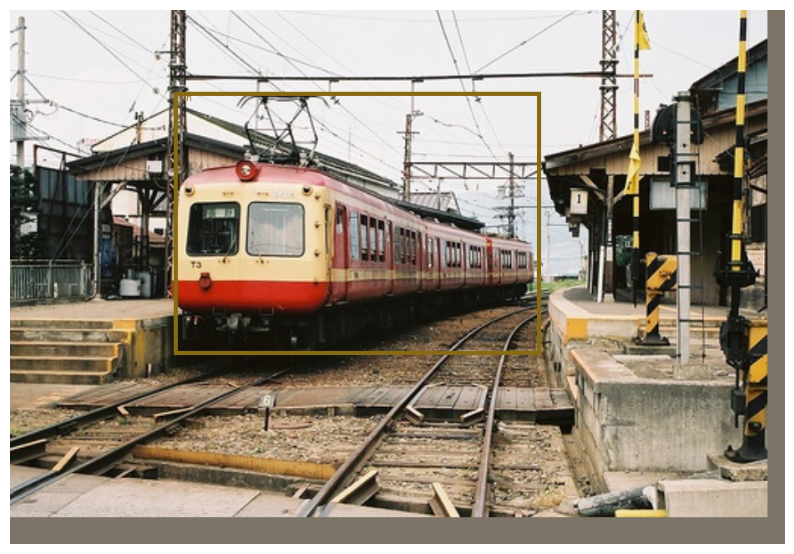

In [24]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=True)

##### Prediction

<class 'torch.Tensor'>


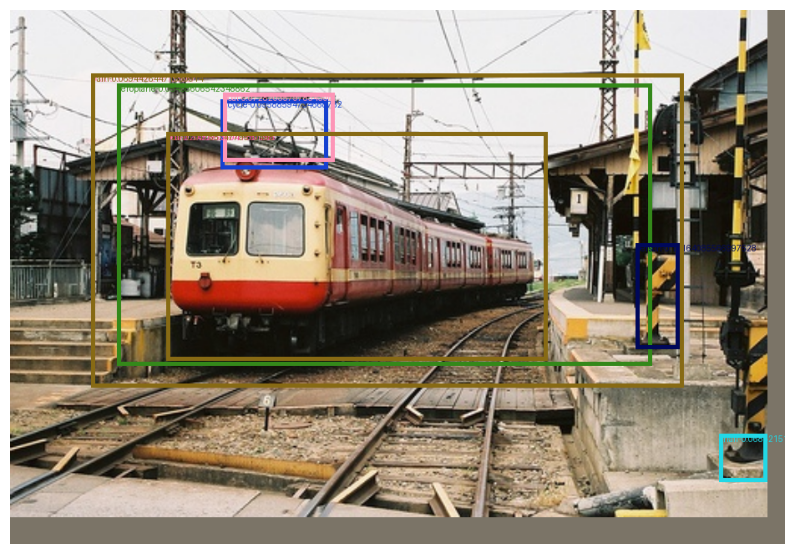

In [25]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=False, model=retinanet_FL)